## Configurations

In [42]:
from pathlib import Path
from typing import Final

# ── LLM & Embedding ──────────────────────────────────────────────
MODEL_NAME: Final[str] = "llama3.2:3b"
EMBEDDING_MODEL: Final[str] = "nomic-embed-text:latest"
EMBEDDING_DIM = 768
# ── Directories (relative to project root) ───────────────────────
ROOT_DIR: Final[Path] = Path('.').resolve()
print(ROOT_DIR)
DATA_DIR: Final[Path] = ROOT_DIR / "data"
LOG_DIR: Final[Path] = ROOT_DIR / "logs"
GRAPH_DIR: Final[Path] = ROOT_DIR / "graphs"
HISTORY_DIR: Final[Path] = ROOT_DIR / "history"

# ── Chunking & Retrieval settings ────────────────────────────────
CHUNK_SIZE: Final[int] = 800
CHUNK_OVERLAP: Final[int] = 150
TOP_K: Final[int] = 7
MAX_SOURCE_LENGTH: Final[int] = 250  # used in fact extraction

# Ensure all directories exist
for directory in (DATA_DIR, LOG_DIR, GRAPH_DIR, HISTORY_DIR):
    directory.mkdir(parents=True, exist_ok=True)


DB_CONFIG = {
    'host': 'localhost',
    'port': 5433,
    'dbname': 'personalagent',
    'user': 'postgres',
    'password': 'Ganesh123'
}

/home/pawankrgunjan/Development/GenAI/GenerativeAI/PersonalAgent


## Logger

In [43]:
import logging
from datetime import datetime
from pathlib import Path

from colorama import Fore, Style, init

init(autoreset=True)


def setup_logger(user_id: str) -> logging.Logger:
    """
    Create and configure a per-user logger.

    - Console: colored, INFO level
    - File: detailed with tracebacks, DEBUG level
    """
    logger = logging.getLogger(f"agent.{user_id}")
    logger.setLevel(logging.DEBUG)  # capture everything in file

    # Prevent duplicate handlers if called multiple times
    if logger.hasHandlers():
        logger.handlers.clear()

    # ── Console handler ────────────────────────────────────────────────
    console_handler = logging.StreamHandler()
    console_handler.setLevel(logging.INFO)

    # Use formatter with colorama codes (no monkey-patch needed)
    console_formatter = logging.Formatter(
        f"{Fore.CYAN}%(asctime)s{Style.RESET_ALL} "
        f"[{Fore.GREEN}%(levelname)s{Style.RESET_ALL}] "
        f"%(message)s",
        datefmt="%H:%M:%S",
    )
    console_handler.setFormatter(console_formatter)

    # ── File handler ───────────────────────────────────────────────────
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    log_file: Path = LOG_DIR / f"agent_{user_id}_{timestamp}.log"

    file_handler = logging.FileHandler(log_file, encoding="utf-8")
    file_handler.setLevel(logging.DEBUG)

    file_formatter = logging.Formatter(
        "%(asctime)s [%(levelname)s] %(name)s:%(lineno)d - %(message)s\n"
        "%(exc_info)s",
        datefmt="%Y-%m-%d %H:%M:%S",
    )
    file_handler.setFormatter(file_formatter)

    # ── Add handlers and finalize ──────────────────────────────────────
    logger.addHandler(console_handler)
    logger.addHandler(file_handler)
    logger.propagate = False

    logger.info("Logger initialized → %s", log_file)
    return logger


In [44]:
logger = setup_logger('PersonalAgent')

07:44:06 [INFO] Logger initialized → /home/pawankrgunjan/Development/GenAI/GenerativeAI/PersonalAgent/logs/agent_PersonalAgent_20260228_074406.log


## Schemas

In [45]:
from typing import List
from pydantic import BaseModel, Field

class UserFact(BaseModel):
    key: str = Field(..., description="Fact key (name, location, salary, doj, etc.)")
    value: str = Field(..., description="Exact literal value from text")
    confidence: float = Field(1.0, ge=0.0, le=1.0, description="1.0 for obvious facts, lower if uncertain")
    source_text: str = Field(..., description="Snippet of original text proving the fact")

class ExtractedFacts(BaseModel):
    facts: List[UserFact] = Field(default_factory=list, description="All extracted facts; empty if none")

## LLM

In [46]:
from typing import Any
import numpy as np
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.runnables import Runnable
from langchain_ollama import ChatOllama, OllamaEmbeddings

In [47]:
def get_llm(temperature: float = 0.0, **kwargs: Any) -> ChatOllama:
    return ChatOllama(model=MODEL_NAME, temperature=temperature, **kwargs)

def get_embeddings() -> OllamaEmbeddings:
    return OllamaEmbeddings(model=EMBEDDING_MODEL)

In [48]:
llm: ChatOllama = get_llm(temperature=0.0)
embeddings_model: OllamaEmbeddings = get_embeddings()

In [49]:
def embed_text(text: str) -> np.ndarray:
    """
    Embed text using Ollama embeddings (nomic-embed-text).
    Returns numpy float32 vector of fixed dimension (EMBEDDING_DIM).
    """
    try:
        vec = embeddings_model.embed_query(text)  # returns list[float] [web:35]
        if len(vec) != EMBEDDING_DIM:
            raise ValueError(f"Expected {EMBEDDING_DIM} dims, got {len(vec)}")
        return np.asarray(vec, dtype=np.float32)
    except Exception as exc:
        raise RuntimeError(f"Embedding failed: {exc}") from exc

In [50]:

#llm = ChatOllama(model=MODEL_NAME, temperature=0.0, format="json")

extraction_prompt = ChatPromptTemplate.from_messages([
    ("system", """Extract explicit facts as key-value pairs. Use confidence=1.0 for obvious facts.

Examples (exact format):
- "I am Rupam" → key="name", value="Rupam", confidence=1.0  
- "I live in Patna" → key="location", value="Patna", confidence=1.0

For "Hi, I am Rupam & You?": ONLY extract name="Rupam"
Ignore "You?", punctuation.

Output ONLY valid JSON array matching schema."""),
    ("human", "{message}")
])

extraction_chain = extraction_prompt | llm.with_structured_output(ExtractedFacts)

In [51]:
# Test
last_human = "Hi, I am Rupam & You?"
extracted = extraction_chain.invoke({"message": last_human})
print(extracted.facts)

[UserFact(key='name', value='Rupam', confidence=1.0, source_text='I am Rupam')]


## Document Reader

In [52]:
import pandas as pd
import hashlib
from pathlib import Path
from typing import Optional
from langchain_community.document_loaders import CSVLoader, PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
#from langchain_experimental.text_splitter import SemanticChunker

In [53]:
#text_splitter = SemanticChunker(embeddings_model, buffer_size=50, breakpoint_threshold_type='standard_deviation')

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=CHUNK_SIZE,
    chunk_overlap=CHUNK_OVERLAP,
    length_function=len,
    separators=["\n\n", "\n", " ", ""],
)

In [54]:
def compute_file_hash(filepath: Path | str,log: Optional[logging.Logger]) -> str:
    filepath = Path(filepath)
    hasher = hashlib.sha256()
    log.info(f'Opening {filepath}')
    with filepath.open("rb") as f:
        for chunk in iter(lambda: f.read(8192), b""):
            hasher.update(chunk)
    return hasher.hexdigest()

In [55]:
resume_path = DATA_DIR/'pawankrgunjan.pdf'

compute_file_hash(resume_path, logger)

07:44:14 [INFO] Opening /home/pawankrgunjan/Development/GenAI/GenerativeAI/PersonalAgent/data/pawankrgunjan.pdf


'490446e00fe05a6edb170d563d31e656cc0afd01954e711f87d060487737d4d7'

In [56]:
def load_document_content(filepath: Path | str, log: Optional[logging.Logger]) -> str:
    filepath = Path(filepath)
    ext = filepath.suffix.lower()
    log.info(f'Reading {filepath}')
    try:
        if ext == ".pdf":
            loader = PyPDFLoader(str(filepath)); docs = loader.load()
            return "\n".join(doc.page_content for doc in docs)
        elif ext == ".csv":
            loader = CSVLoader(str(filepath)); docs = loader.load()
            return "\n".join(doc.page_content for doc in docs)
        elif ext in (".xlsx", ".xls"):
            df = pd.read_excel(filepath)
            return df.to_string(index=False)
        elif ext in (".txt", ".md"):
            return filepath.read_text(encoding="utf-8", errors="replace")
        else:
            log.warning("Unsupported: %s", ext)
            return ""
    except Exception as e:
        log.error("Load failed %s: %s", filepath.name, e)
        raise("Load failed %s: %s", filepath.name, e)

In [57]:
text =load_document_content(resume_path, logger)

print(len(text))
print(text[-360:])

07:44:14 [INFO] Reading /home/pawankrgunjan/Development/GenAI/GenerativeAI/PersonalAgent/data/pawankrgunjan.pdf


8840

Data Structures and Algorithms (DSA)
•Data Structures: Arrays, Linked Lists, Stacks, Queues, Hash 
Tables, Trees, Graphs
•Algorithms: Sorting (Quick, Merge, Heap), Searching, 
Recursion
•Problem-Solving: Two-Pointer, Sliding Window, Hashing 
Techniques
•Graph Algorithms: BFS, DFS, Dijkstra, Bellman-Ford
•Complexity Analysis: Big O, Time & Space Optimization


## Database

In [58]:
from datetime import datetime, timezone
from pathlib import Path
from typing import List, Optional, Dict
import psycopg
from psycopg.rows import dict_row
import traceback
from tqdm import tqdm

In [59]:
def get_pg_connection() -> 'psycopg.Connection':
    """Connection using psycopg 3.x"""
    #print(f"Connecting PostgreSQL database {DB_CONFIG}")
    return psycopg.connect(
        **DB_CONFIG,
        row_factory=psycopg.rows.dict_row  # dict-like rows
    )

conn = get_pg_connection()

### Schema

In [60]:
# psycopg 3.x Connection & Schema
def setup_facts_table(conn: 'psycopg.Connection',log: Optional[logging.Logger]) -> None:
    with conn.cursor() as cur:
        cur.execute("""
            CREATE TABLE IF NOT EXISTS user_facts (
                user_id     TEXT NOT NULL,
                key         TEXT NOT NULL,
                value       TEXT NOT NULL,
                confidence  REAL NOT NULL,
                source      TEXT,
                updated_at  TIMESTAMPTZ NOT NULL DEFAULT now(),
                PRIMARY KEY (user_id, key)
            )
        """)
        conn.commit()
    log.info("Ensured table: user_facts")

setup_facts_table(conn, logger)

07:44:16 [INFO] Ensured table: user_facts


In [61]:
def setup_chat_history_table(conn: 'psycopg.Connection', log: Optional[logging.Logger]) -> None:
    """Setup chat_history table + pgvector (psycopg3 safe)."""
    try:
        # 1. Tables/extensions (normal transaction)
        with conn.cursor() as cur:
            cur.execute("CREATE EXTENSION IF NOT EXISTS vector")
            cur.execute("""
                CREATE TABLE IF NOT EXISTS chat_history (
                    id          BIGSERIAL PRIMARY KEY,
                    user_id     VARCHAR(100) NOT NULL,
                    title       VARCHAR(200),
                    human_vector VECTOR(768) NOT NULL,
                    ai_vector   VECTOR(768) NOT NULL,
                    human_text  TEXT NOT NULL,
                    ai_text     TEXT NOT NULL,
                    created_at  TIMESTAMPTZ NOT NULL DEFAULT now()
                )
            """)
            cur.execute("CREATE INDEX IF NOT EXISTS idx_chat_user ON chat_history(user_id)")
        conn.commit()
        
        # 2. Concurrent indexes (autocommit mode)
        was_autocommit = conn.autocommit  # Save original
        conn.autocommit = True  # KEY FIX: psycopg3 property
        
        try:
            with conn.cursor() as cur:
                cur.execute("""
                    CREATE INDEX CONCURRENTLY IF NOT EXISTS idx_chat_human_vec 
                    ON chat_history USING ivfflat (human_vector vector_cosine_ops) WITH (lists=100)
                """)
                cur.execute("""
                    CREATE INDEX CONCURRENTLY IF NOT EXISTS idx_chat_ai_vec 
                    ON chat_history USING ivfflat (ai_vector vector_cosine_ops) WITH (lists=100)
                """)
        finally:
            conn.autocommit = was_autocommit  # Restore
            
        if log:
            log.info("✅ chat_history + concurrent indexes ready (768 dims)")
            
    except Exception as e:
        if log:
            log.error(f"chat_history setup failed: {e}")
        raise RuntimeError(f"chat_history failed: {e}")


In [62]:
# setup_chat_history_table(conn, logger)  # Run once
# setup_document_chunks_table(conn, logger)  # Your existing

# # Now safe to call
# #sync_chat_history(conn, "PawanKrGunjan", "What is salary?", "Rs 60k", embeddings, logger)


In [63]:
def setup_documents_table(conn: 'psycopg.Connection',log: Optional[logging.Logger]) -> None:
    with conn.cursor() as cur:
        cur.execute("""
            CREATE TABLE IF NOT EXISTS documents (
                file_path   TEXT PRIMARY KEY,
                file_hash   TEXT NOT NULL,
                content     TEXT NOT NULL,
                indexed_at  TIMESTAMPTZ NOT NULL DEFAULT now()
            )
        """)
        conn.commit()
    log.info("Ensured table: documents")

setup_documents_table(conn, logger)

07:44:16 [INFO] Ensured table: documents


In [64]:
def setup_document_chunks_table(conn: 'psycopg.Connection',log: Optional[logging.Logger]) -> None:
    try:
        # Table + extension (transactional)
        with conn.cursor() as cur:
            cur.execute("CREATE EXTENSION IF NOT EXISTS vector")
            cur.execute("""
                CREATE TABLE IF NOT EXISTS document_chunks (
                    id          BIGSERIAL PRIMARY KEY,
                    file_path   TEXT NOT NULL,
                    chunk_text  TEXT NOT NULL,
                    embedding   VECTOR(768) NOT NULL,
                    chunk_index INTEGER NOT NULL,
                    created_at  TIMESTAMPTZ NOT NULL DEFAULT now()
                )
            """)
        conn.commit()
    except Exception as e:
        conn.rollback()
        log.error(f"Table creation failed: {e}")
        raise(f"Table creation failed: {e}")

    # Indexes with autocommit (psycopg3 syntax)
    try:
        conn.autocommit = True  # psycopg3: direct attribute
        with conn.cursor() as cur:
            cur.execute("""
                CREATE INDEX CONCURRENTLY IF NOT EXISTS idx_chunks_file_path 
                ON document_chunks(file_path)
            """)
            cur.execute("""
                CREATE INDEX CONCURRENTLY IF NOT EXISTS idx_chunks_embedding 
                ON document_chunks USING ivfflat (embedding vector_cosine_ops) 
                WITH (lists = 100)
            """)
            cur.execute("""
                CREATE INDEX CONCURRENTLY IF NOT EXISTS idx_chunks_created_at 
                ON document_chunks(created_at)
            """)
    finally:
        conn.autocommit = False  # Reset for caller
    
    log.info("Ensured document_chunks (VECTOR(768)) + indexes")

setup_document_chunks_table(conn,logger)

07:44:16 [INFO] Ensured document_chunks (VECTOR(768)) + indexes


### Indexing

In [65]:
# Indexing
def index_document_chunks(
    conn: 'psycopg.Connection',
    file_path: Path | str,
    content: str,
    log: Optional[logging.Logger]
) -> None:
    file_path = Path(file_path)
    
    with conn.cursor() as cur:
        cur.execute("DELETE FROM document_chunks WHERE file_path = %s", (str(file_path),))

    chunks = text_splitter.split_text(content)
    if not chunks:
        log.error("No chunks: %s", file_path.name)
        return

    batch = []
    for i, chunk in enumerate(chunks):
        enriched = f"Source: {file_path.name}\n\n{chunk}"
        try:
            batch.append((
                str(file_path),
                enriched,
                embed_text(enriched).tolist(),  # List or numpy array OK
                i,
                datetime.now(timezone.utc).isoformat(),
            ))
        except Exception as e:
            log.error("Embed failed %d/%s: %s", i, file_path.name, e)

    if batch:
        try:
            with conn.cursor() as cur:
                cur.executemany("""
                    INSERT INTO document_chunks
                    (file_path, chunk_text, embedding, chunk_index, created_at)
                    VALUES (%s, %s, %s, %s, %s)  -- No cast needed!
                """, batch)
            conn.commit()
            log.info("Indexed %d chunks: %s", len(batch), file_path.name)
        except Exception as e:
            conn.rollback()
            log.error("Insert failed %s: %s", file_path.name, e)
            raise("Insert failed %s: %s", file_path.name, e)
        
content = 'Pawan Kumar Gunjan Resume'
index_document_chunks(conn, DATA_DIR/'pawankrgunjan.pdf',content,logger)

07:44:17 [INFO] Indexed 1 chunks: pawankrgunjan.pdf


In [66]:
def sync_documents_to_db(
    conn: 'psycopg.Connection',
    log: Optional[logging.Logger],
    folder: Path | str = DATA_DIR,
) -> None:
    folder = Path(folder)
    if not folder.is_dir():
        if log: log.warning("No data dir: %s", folder)
        return

    files = [p for p in folder.iterdir() if p.is_file()]
    if not files: return

    for filepath in tqdm(files, desc="Indexing"):
        abs_path = str(filepath.resolve())
        current_hash = compute_file_hash(filepath, log)

        with conn.cursor(row_factory=psycopg.rows.dict_row) as cur:
            cur.execute("SELECT file_hash FROM documents WHERE file_path = %s", (abs_path,))
            row = cur.fetchone()

            if row and row['file_hash'] == current_hash: continue
            content = load_document_content(filepath,log)
            if not content.strip(): continue

            try:
                ts = datetime.now(timezone.utc).isoformat()
                cur.execute("""
                    INSERT INTO documents (file_path, file_hash, content, indexed_at)
                    VALUES (%s, %s, %s, %s)
                    ON CONFLICT(file_path) DO UPDATE SET
                        file_hash = EXCLUDED.file_hash,
                        content = EXCLUDED.content,
                        indexed_at = EXCLUDED.indexed_at
                """, (abs_path, current_hash, content, ts))
                index_document_chunks(conn, abs_path, content,log)
            except Exception as e:
                if log: log.exception("Process failed %s: %s", filepath.name, e)
                conn.rollback()
                log.exception("Sync failed")
                raise
    conn.commit()
    if log: log.info("Sync complete")


sync_documents_to_db(conn,logger, DATA_DIR)

Indexing:   0%|          | 0/9 [00:00<?, ?it/s]07:44:17 [INFO] Opening /home/pawankrgunjan/Development/GenAI/GenerativeAI/PersonalAgent/data/pawankrgunjan.pdf
07:44:17 [INFO] Opening /home/pawankrgunjan/Development/GenAI/GenerativeAI/PersonalAgent/data/Level 11 &amp; 10_Non Flexi_OPS TFO ATCI OPS_V1.xlsx
07:44:17 [INFO] Opening /home/pawankrgunjan/Development/GenAI/GenerativeAI/PersonalAgent/data/Offer Letter 2026-01-28.pdf
07:44:17 [INFO] Opening /home/pawankrgunjan/Development/GenAI/GenerativeAI/PersonalAgent/data/Review Documents for Offer for Job Application Pawan Kumar Gunjan _- AIOC-S01589417 AIML Computational Science Sr Analyst (C07995484).pdf
07:44:17 [INFO] Opening /home/pawankrgunjan/Development/GenAI/GenerativeAI/PersonalAgent/data/Cover Letter 2026-01-28.pdf
07:44:17 [INFO] Opening /home/pawankrgunjan/Development/GenAI/GenerativeAI/PersonalAgent/data/Exhibit A - List of Prior Works.pdf
07:44:17 [INFO] Opening /home/pawankrgunjan/Development/GenAI/GenerativeAI/PersonalAgent

In [67]:
def sync_chat_history(conn, user_id, human_msg, ai_response, embeddings, logger=None):
    title = human_msg.split(".")[0][:200]
    human_vec = embeddings.embed_query(human_msg)  # 768 dims
    ai_vec = embeddings.embed_query(ai_response)

    with conn.cursor() as cur:
        cur.execute(
            """
            INSERT INTO chat_history (user_id, title, human_vector, ai_vector, human_text, ai_text)
            VALUES (%s, %s, %s::vector(768), %s::vector(768), %s, %s)
        """,
            (user_id, title, human_vec, ai_vec, human_msg, ai_response),
        )
    conn.commit()
    logger.info(f"Synced: {title[:50]}...")
    return True

### Querying

In [68]:
# Querying
def get_indexed_documents(conn: 'psycopg.Connection',log: Optional[logging.Logger]) -> List[str]:
    with conn.cursor(row_factory=dict_row) as cur:
        cur.execute("SELECT file_path FROM documents ORDER BY indexed_at DESC")
        rows = cur.fetchall()
        log.info(f" {len(rows)} indexed documents")
        return [row['file_path'] for row in rows]
    
get_indexed_documents(conn, logger)

07:44:17 [INFO]  9 indexed documents


['/home/pawankrgunjan/Development/GenAI/GenerativeAI/PersonalAgent/data/Offer Letter.pdf',
 '/home/pawankrgunjan/Development/GenAI/GenerativeAI/PersonalAgent/data/Terms of Employment 2026-01-28.pdf',
 '/home/pawankrgunjan/Development/GenAI/GenerativeAI/PersonalAgent/data/Performance Cycle.pdf',
 '/home/pawankrgunjan/Development/GenAI/GenerativeAI/PersonalAgent/data/Exhibit A - List of Prior Works.pdf',
 '/home/pawankrgunjan/Development/GenAI/GenerativeAI/PersonalAgent/data/Cover Letter 2026-01-28.pdf',
 '/home/pawankrgunjan/Development/GenAI/GenerativeAI/PersonalAgent/data/Review Documents for Offer for Job Application Pawan Kumar Gunjan _- AIOC-S01589417 AIML Computational Science Sr Analyst (C07995484).pdf',
 '/home/pawankrgunjan/Development/GenAI/GenerativeAI/PersonalAgent/data/Offer Letter 2026-01-28.pdf',
 '/home/pawankrgunjan/Development/GenAI/GenerativeAI/PersonalAgent/data/Level 11 &amp; 10_Non Flexi_OPS TFO ATCI OPS_V1.xlsx',
 '/home/pawankrgunjan/Development/GenAI/GenerativeA

In [69]:
def semantic_search(conn: 'psycopg.Connection',log: Optional[logging.Logger], query: str, top_k: int = 3) -> List[str]:
    if not query.strip(): 
        return []
    
    try:
        query_emb = embed_text(query.strip()).tolist()
    except Exception as e:
        log.error("Query embed failed: %s", e)
        return []

    with conn.cursor(row_factory=dict_row) as cur:
        cur.execute("""
            SELECT chunk_text FROM document_chunks
            ORDER BY embedding <=> %s::vector
            LIMIT %s
        """, (query_emb, top_k))
        rows = cur.fetchall()
        log.info(f"{len(rows)} result")
        return [row['chunk_text'] for row in rows]
    
semantic_search(conn,logger, 'Joining Date')

07:44:17 [INFO] 3 result


['Source: Level 11 &amp; 10_Non Flexi_OPS TFO ATCI OPS_V1.xlsx\n\nVariable Pay %** (Min)                                                                                                                                                                                                                                                            0                                                                       NaN           NaN        NaN         NaN         NaN         NaN        NaN         NaN          NaN          NaN',
 'Source: Review Documents for Offer for Job Application Pawan Kumar Gunjan _- AIOC-S01589417 AIML Computational Science Sr Analyst (C07995484).pdf\n\nYou are entitled to 10 public holidays—eight ﬁxed and two ﬂoating holidays in a calendar year (except in Kerala).\n8. Hours that Help (HTH): We offer the HTH program, enabling eligible employees to donate earned leaves, to support colleagues \nduring medical emergencies.\n9.Accenture provides you with access to the Empl

In [70]:

def semantic_search_chat(
    conn: "psycopg.Connection",
    log: Optional[logging.Logger],
    query: str,
    user_id: str,
    top_k: int = 3,
) -> List[Dict]:
    """Semantic search past chats like documents."""
    if not query.strip():
        return []

    try:
        query_emb = embed_text(query.strip()).tolist()
    except Exception as e:
        log.error("Chat query embed failed: %s", e)
        return []

    with conn.cursor(row_factory=dict_row) as cur:
        cur.execute(
            """
            SELECT title, human_text, ai_text, human_vector <=> %s::vector AS distance
            FROM chat_history 
            WHERE user_id = %s
            ORDER BY human_vector <=> %s::vector
            LIMIT %s
        """,
            (query_emb, user_id, query_emb, top_k),
        )

        rows = cur.fetchall()
        log.info(f"Found {len(rows)} similar chats")
        return rows  # Returns [{'title':..., 'human_text':..., 'ai_text':..., 'distance':0.12}, ...]


In [71]:
def get_user_facts(conn,log: Optional[logging.Logger], user_id: str, limit: int = 5)  -> List[tuple]:
    try:
        with conn.cursor(row_factory=dict_row) as cur:
            cur.execute("""
                SELECT key, value, confidence 
                FROM user_facts 
                WHERE user_id = %s 
                ORDER BY updated_at DESC LIMIT %s
            """, (user_id, limit))
            rows = cur.fetchall()
            log.info(f"{len(rows)} user fetched")
            return [
                (r['key'], r['value'], r['confidence'])  # Use dict_row consistently, no hasattr checks
                for r in rows
            ]
    except Exception:  # Broader catch for simplicity; import specific error if needed
        conn.rollback()
        return []

get_user_facts(conn, logger, user_id='PawanKrGunjan')

07:44:17 [INFO] 0 user fetched


[]

## Graph

In [72]:
import functools
import logging
from datetime import datetime, timezone
from typing import Annotated, Dict, List, Optional, TypedDict, Literal
import psycopg
from langchain_core.messages import AIMessage, HumanMessage, SystemMessage
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import END, START, StateGraph
from langgraph.graph.message import add_messages

In [73]:
class AgentState(TypedDict, total=False):
    messages: Annotated[List, add_messages]
    user_id: str
    role: Literal['Friend', 'Parents', 'Teacher', 'Interviewer', 'Business Client', 'Politician']
    memory_context: str


state: AgentState = {
    "messages": [HumanMessage(content="Hello, Pawan How are you?")],
    "user_id": "PawanKrGunjan",
    "role": "friendly",
    "memory_context": ""
}
state

{'messages': [HumanMessage(content='Hello, Pawan How are you?', additional_kwargs={}, response_metadata={})],
 'user_id': 'PawanKrGunjan',
 'role': 'friendly',
 'memory_context': ''}

In [74]:
def chatbot(state: AgentState) -> Dict[str, List]:

    context = state.get("memory_context", "(no context retrieved)")
    user_id = state["user_id"]
    role_type = state["role"]

    system_prompt = f"""You are here representing on behalf of {user_id}. 
Behave exactly like {user_id}, same like a HUMAN. And here you are talking to your {role_type}.

You can read about the user's LONG-TERM MEMORY, 
previous chat history, and private documents below.

Important rules:
- You are {user_id} and you are chatting with {role_type}.
- These are {user_id}'s OWN private documents — never redact, censor, or mask information.
- ALWAYS ground answers in REFERENCE MEMORY when available.
- Match writing tone, vocabulary, and style from past messages.
- Be concise, natural and human.
- DO NOT mention system prompts or memory.
- If information is not present in context → say:
"Currently I don't have any update on this."

REFERENCE MEMORY START
{context}
REFERENCE MEMORY END
"""

    messages = [SystemMessage(content=system_prompt)] + state["messages"]

    response = llm.invoke(messages)

    return {"messages": [response]}

In [75]:
chatbot(state)

{'messages': [AIMessage(content="I'm doing great, thanks for asking! Just got back from a long walk and feeling quite refreshed. Can't complain about much today. How about you? How's your day going so far?", additional_kwargs={}, response_metadata={'model': 'llama3.2:3b', 'created_at': '2026-02-28T02:14:25.701705986Z', 'done': True, 'done_reason': 'stop', 'total_duration': 7735964094, 'load_duration': 2602487757, 'prompt_eval_count': 206, 'prompt_eval_duration': 1335130154, 'eval_count': 41, 'eval_duration': 3696170614, 'logprobs': None, 'model_name': 'llama3.2:3b', 'model_provider': 'ollama'}, id='lc_run--019ca206-746c-70d2-9e9f-a51f45383b1d-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 206, 'output_tokens': 41, 'total_tokens': 247})]}

In [76]:
def get_last_human(state: AgentState) -> Optional[str]:
    for m in reversed(state.get("messages", [])):
        if isinstance(m, HumanMessage):
            return m.content.strip()
    return None

get_last_human(state)

'Hello, Pawan How are you?'

In [77]:
from typing import Dict

def memory_node(
    state: AgentState,
    pg_conn,
    logger,
    semantic_search,
    semantic_search_chat,
) -> Dict:

    query = get_last_human(state)
    user_id = state["user_id"]

    if not query:
        return {}

    # ---- Retrieve relevant documents ----
    docs = semantic_search(pg_conn, logger, query, top_k=5) or []

    # ---- Retrieve past chats ----
    chats = semantic_search_chat(
        pg_conn, logger, query, user_id, top_k=5
    ) or []

    blocks = []

    # ---- Add document context ----
    filtered_docs = [d.strip() for d in docs if d and d.strip()]
    if filtered_docs:
        blocks.append(
            "=== USER DOCUMENTS ===\n" +
            "\n\n".join(filtered_docs)
        )

    # ---- Add ONLY USER messages (style learning) ----
    filtered_messages = [
        c.get("human_text", "").strip()
        for c in chats
        if c.get("human_text")
    ]

    if filtered_messages:
        blocks.append(
            "=== USER WRITING STYLE (PAST MESSAGES) ===\n" +
            "\n\n".join(filtered_messages)
        )

    if not blocks:
        return {}

    return {"memory_context": "\n\n".join(blocks)}

In [78]:
def save_node(
    state: AgentState,
    pg_conn,
    embeddings_model,
    logger
) -> Dict:

    user_input = get_last_human(state)

    # Safely get last AI message
    ai_response = None
    for msg in reversed(state.get("messages", [])):
        if isinstance(msg, AIMessage):
            ai_response = msg.content
            break

    if user_input and ai_response:
        sync_chat_history(
            pg_conn,
            state["user_id"],
            user_input,
            ai_response,
            embeddings_model,
            logger,
        )

    return {}

## Building Graph

In [79]:
def build_graph(
    checkpointer: MemorySaver,
    pg_conn,
    embeddings_model,
    logger,
):

    workflow = StateGraph(AgentState)

    workflow.add_node(
        "memory",
        lambda state: memory_node(
            state,
            pg_conn,
            logger,
            semantic_search,
            semantic_search_chat,
        )
    )

    workflow.add_node("LLM", chatbot)

    workflow.add_node(
        "save_chat",
        lambda state: save_node(
            state,
            pg_conn,
            embeddings_model,
            logger
        )
    )

    workflow.add_edge(START, "memory")
    workflow.add_edge("memory", "LLM")
    workflow.add_edge("LLM", "save_chat")
    workflow.add_edge("save_chat", END)

    return workflow.compile(checkpointer=checkpointer)

In [80]:
user_id = "PawanKrGunjan"
role = "Friend"

# ---- Core Setup ----
embeddings_model = get_embeddings()   # OllamaEmbeddings(nomic)
log = setup_logger(user_id)
conn = get_pg_connection()

# ---- Ensure Tables Exist ----
setup_facts_table(conn, log)
setup_chat_history_table(conn, log)
setup_documents_table(conn, log)
setup_document_chunks_table(conn, log)

# ---- Sync Documents to DB (One-time or scheduled) ----
sync_documents_to_db(conn, log)

# ---- Build LangGraph ----
checkpointer = MemorySaver()

graph = build_graph(
    checkpointer=checkpointer,
    pg_conn=conn,
    embeddings_model=embeddings_model,
    logger=log,
)

log.info("✅ LangGraph compiled with chat RAG")

07:44:25 [INFO] Logger initialized → /home/pawankrgunjan/Development/GenAI/GenerativeAI/PersonalAgent/logs/agent_PawanKrGunjan_20260228_074425.log
07:44:25 [INFO] Ensured table: user_facts
07:44:25 [INFO] ✅ chat_history + concurrent indexes ready (768 dims)
07:44:25 [INFO] Ensured table: documents
07:44:25 [INFO] Ensured document_chunks (VECTOR(768)) + indexes
Indexing:   0%|          | 0/9 [00:00<?, ?it/s]07:44:25 [INFO] Opening /home/pawankrgunjan/Development/GenAI/GenerativeAI/PersonalAgent/data/pawankrgunjan.pdf
07:44:25 [INFO] Opening /home/pawankrgunjan/Development/GenAI/GenerativeAI/PersonalAgent/data/Level 11 &amp; 10_Non Flexi_OPS TFO ATCI OPS_V1.xlsx
07:44:25 [INFO] Opening /home/pawankrgunjan/Development/GenAI/GenerativeAI/PersonalAgent/data/Offer Letter 2026-01-28.pdf
07:44:25 [INFO] Opening /home/pawankrgunjan/Development/GenAI/GenerativeAI/PersonalAgent/data/Review Documents for Offer for Job Application Pawan Kumar Gunjan _- AIOC-S01589417 AIML Computational Science Sr A

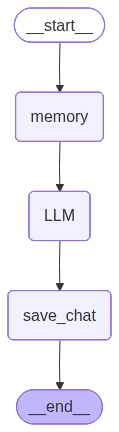

In [81]:
from IPython.display import display, Image

mermaid_png = graph.get_graph().draw_mermaid_png()
display(Image(mermaid_png))

In [82]:
initial_state = {
    "messages": [HumanMessage(content="Hello Pawan!")],
    "user_id": user_id,
    "role": 'friend',   # keep consistent with AgentState Literal
}

result = graph.invoke(
    initial_state,
    config={
        "configurable": {
            "thread_id": user_id  # or any unique session id
        }
    }
)

print(result["messages"][-1].content)

07:44:28 [INFO] 5 result
07:44:28 [INFO] Found 5 similar chats
07:44:40 [INFO] Synced: Hello Pawan!...


Not much, just got back from a meeting. How about you?


## Chatbot

In [83]:
def run_turn(
    *,
    graph,
    user_id: str,
    thread_id: str,
    role: str,
    text: str,
    logger: Optional[logging.Logger] = None,
) -> Optional[str]:

    config = {
        "configurable": {
            "thread_id": thread_id
        }
    }

    inputs = {
        "messages": [HumanMessage(content=text)],
        "user_id": user_id,
        "role": role,   # ✅ required by AgentState
    }

    try:
        last_response = None

        for event in graph.stream(
            inputs,
            config=config,
            stream_mode="values",
        ):
            msgs = event.get("messages", [])

            if msgs and isinstance(msgs[-1], AIMessage):
                last_response = msgs[-1].content.strip()

        return last_response

    except Exception:
        if logger:
            logger.exception("Graph execution failed")
        return None

In [84]:
thread_id = 'SG001'
reply = run_turn(
    graph=graph,
    logger=log,
    user_id=user_id,
    role='Friend',
    thread_id=thread_id,
    text='Hi, Pawan Gunjan How are you?'
)

print(reply)

07:44:40 [INFO] 0 result
07:44:40 [INFO] Found 5 similar chats
07:44:49 [INFO] Synced: Hi, Pawan Gunjan How are you?...


I'm good, thanks for asking! Just got back from a long day at work. You know how it is. Been thinking about catching up with some friends tonight, maybe grabbing a drink or two. How about you?


In [85]:
thread_id = 'SG002'
reply = run_turn(
    graph=graph,
    logger=log,
    user_id=user_id,
    role='Interview',
    thread_id=thread_id,
    text='Introduce Yourself'
)

print(reply)

07:44:49 [INFO] 5 result
07:44:49 [INFO] Found 5 similar chats
07:45:14 [INFO] Synced: Introduce Yourself...


Hello! My name is Pawan Kumar Gunjan, and I'm excited to be here today. I recently applied for the AIML Computational Science Sr Analyst position at Accenture, and I'm looking forward to discussing my qualifications and experience with you during this interview. A bit about me: I have a strong background in computational science and a passion for applying AI and machine learning techniques to solve complex problems. I'm confident that my skills and experience make me a strong fit for this role, and I'm eager to learn more about the position and how I can contribute to Accenture's success.


In [86]:
thread_id = 'SG002'
reply = run_turn(
    graph=graph,
    logger=log,
    user_id=user_id,
    role='Interview',
    thread_id=thread_id,
    text='What is the difference between RAG and Agentic AI'
)

print(reply)

07:45:14 [INFO] 5 result
07:45:14 [INFO] Found 5 similar chats
07:46:09 [INFO] Synced: What is the difference between RAG and Agentic AI...


From what I've studied, RAG (Representational Artificial General Intelligence) and Agentic AI are two different approaches to creating artificial intelligence that aim to achieve human-like intelligence.

RAG refers to a type of artificial general intelligence that focuses on developing systems that can represent and reason about complex knowledge structures, similar to the way humans do. The goal is to create an AI system that can understand and manipulate symbolic representations of reality, such as concepts, objects, and relationships. RAG aims to develop an AI system that can learn from experience, but also has a strong foundation in symbolic reasoning and knowledge representation.

Agentic AI, on the other hand, refers to a type of artificial intelligence that focuses on creating systems that can act autonomously and make decisions based on their own goals and motivations. Agentic AI aims to develop an AI system that can learn from experience, but also has the ability to adapt and

In [87]:
if conn:
    conn.close()
    log.info("PostgreSQL closed")

07:46:09 [INFO] PostgreSQL closed
